In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp "/content/drive/MyDrive/violenceDetection/aiEngine.zip" /content/

In [4]:
!unzip -q /content/aiEngine.zip

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [6]:
#src path
sys.path.append('/content/aiEngine/src')

In [7]:
from generator import VideoGenerator

In [9]:
#loading trained model
model = load_model(
    '/content/drive/MyDrive/violenceDetection/models/best_model.keras'
)

print("Model loaded successfully.")

Model loaded successfully.


In [15]:
#regenerating metadata
import os
import pandas as pd

dataset_dir = "/content/aiEngine/dataset/raw"

records = []

classes = {
    "Violence": 1,
    "NonViolence": 0
}

for class_name, label in classes.items():

    class_path = os.path.join(
        dataset_dir,
        class_name
    )

    for video_name in os.listdir(class_path):

        if video_name.endswith(
            (".mp4", ".avi", ".mov", ".mkv")
        ):

            full_path = os.path.join(
                class_path,
                video_name
            )

            records.append({
                "video_path": full_path,
                "label": label,
                "class_name": class_name
            })

df = pd.DataFrame(records)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.to_csv(
    "/content/aiEngine/dataset/metadata.csv",
    index=False
)

print("Metadata regenerated.")
print(df.head())

Metadata regenerated.
                                          video_path  label   class_name
0  /content/aiEngine/dataset/raw/NonViolence/NV_1...      0  NonViolence
1   /content/aiEngine/dataset/raw/Violence/V_535.mp4      1     Violence
2  /content/aiEngine/dataset/raw/NonViolence/NV_9...      0  NonViolence
3   /content/aiEngine/dataset/raw/Violence/V_884.mp4      1     Violence
4  /content/aiEngine/dataset/raw/NonViolence/NV_4...      0  NonViolence


In [16]:
#splits
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    '/content/aiEngine/dataset/metadata.csv'
)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

train_df.to_csv(
    '/content/aiEngine/dataset/splits/train.csv',
    index=False
)

val_df.to_csv(
    '/content/aiEngine/dataset/splits/val.csv',
    index=False
)

test_df.to_csv(
    '/content/aiEngine/dataset/splits/test.csv',
    index=False
)

print("Splits regenerated.")

Splits regenerated.


In [17]:
test_generator = VideoGenerator(
    csv_path='/content/aiEngine/dataset/splits/test.csv',
    batch_size=4,
    shuffle=False
)

In [18]:
predictions = model.predict(
    test_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step


In [19]:
y_pred = (
    predictions > 0.5
).astype(int).flatten()

In [20]:
y_true = test_generator.data[
    'label'
].values

In [21]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NonViolence",
            "Violence"
        ]
    )
)

              precision    recall  f1-score   support

 NonViolence       0.99      0.99      0.99       150
    Violence       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



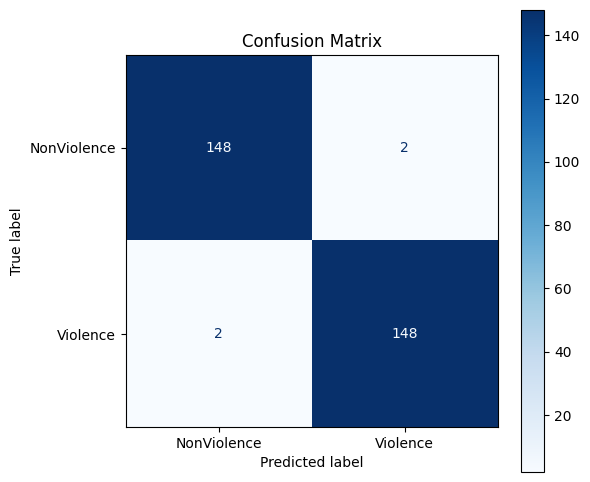

In [28]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "NonViolence",
        "Violence"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/violenceDetection/confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "NonViolence",
        "Violence"
    ]
)

print(report)

with open(
    "/content/drive/MyDrive/violenceDetection/classification_report.txt",
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

 NonViolence       0.99      0.99      0.99       150
    Violence       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [31]:
with open(
    "/content/drive/MyDrive/violenceDetection/model_summary.txt",
    "w"
) as f:

    model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )